In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt

In [3]:
tomato1 = pd.read_csv('Tomato.csv', index_col=0, parse_dates=True)
tomato1.head()

,Unit,Minimum,Maximum,Average,Market
Date,,,,,
2013-06-16,Kg,26,32,29.0,Tomato
2013-06-17,Kg,20,25,22.5,Tomato
2013-06-18,Kg,22,26,24.0,Tomato
2013-06-19,Kg,24,28,26.0,Tomato
2013-06-20,Kg,22,26,24.0,Tomato


In [4]:
tomato_2019 = tomato1[tomato1.index.year == 2019]
tomato_2019 = tomato_2019[['Average']]

In [5]:
tomato_2019.head()

,Average
Date,
2019-01-01,22.5
2019-01-02,22.5
2019-01-03,22.5
2019-01-04,22.5
2019-01-05,25.0


In [6]:
tomato_2019.shape

(363, 1)

In [7]:
tomato_2019.describe()

,Average
count,363.000000
mean,45.410468
std,18.632743
min,17.500000
25%,32.500000
50%,42.500000
75%,57.500000
max,117.500000


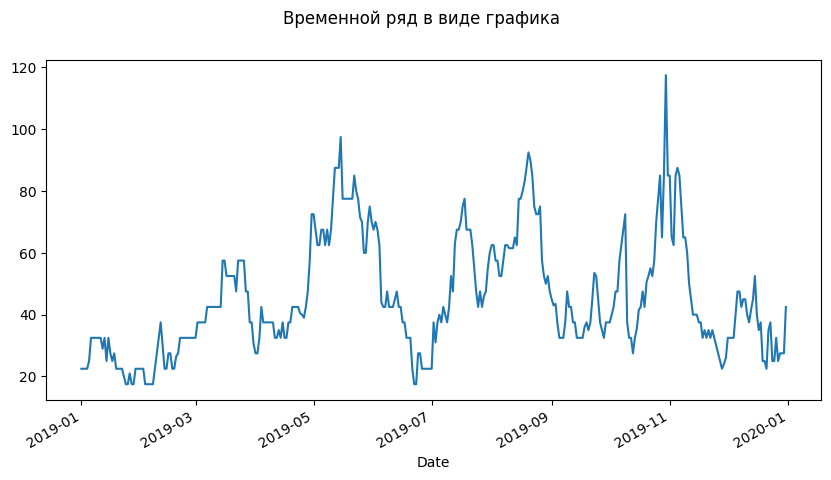

In [8]:
# визуализация временного ряда
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд в виде графика')
tomato_2019.plot(ax=ax, legend=False)
pyplot.show()

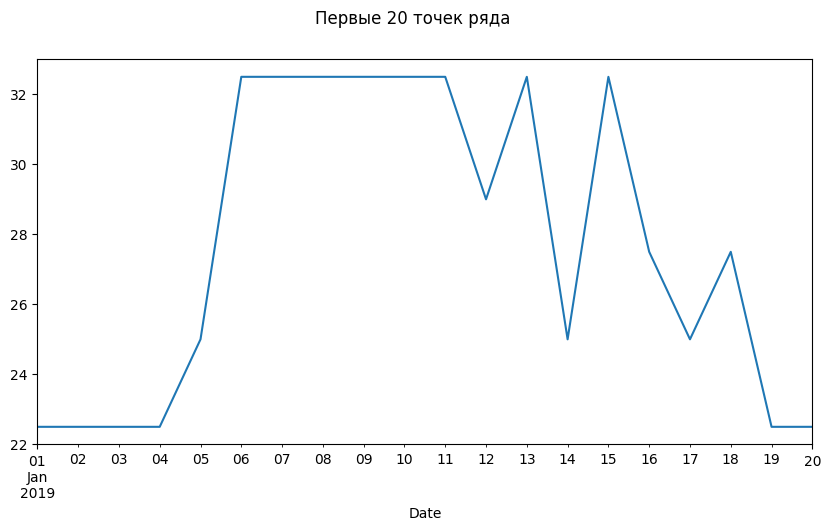

In [9]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Первые 20 точек ряда')
tomato_2019[:20].plot(ax=ax, legend=False)
pyplot.show()

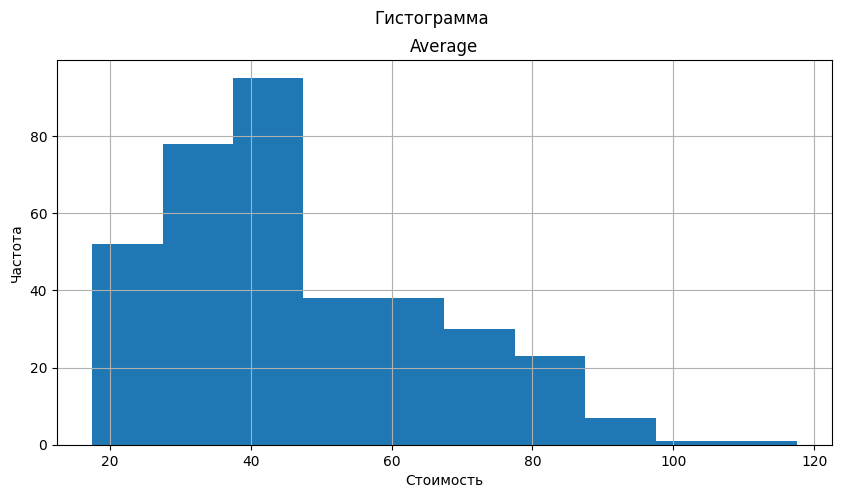

In [10]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
tomato_2019.hist(ax=ax, legend=False)
ax.set_xlabel('Стоимость')
ax.set_ylabel('Частота')
pyplot.show()

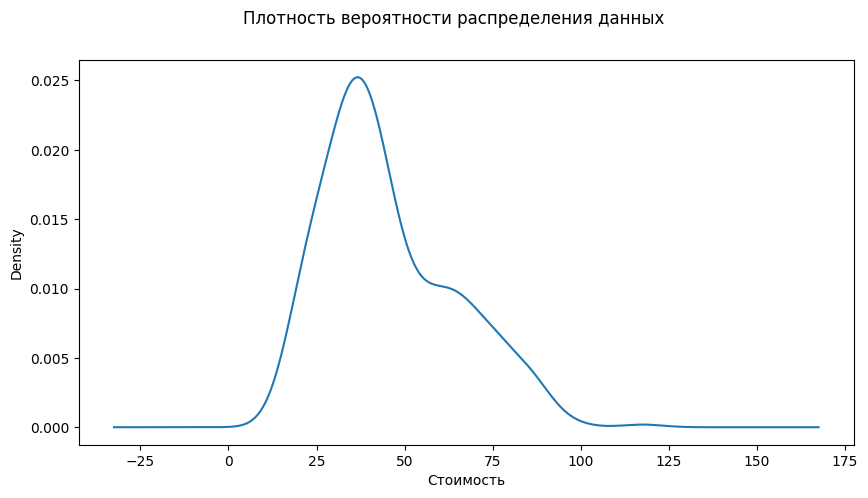

In [11]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Плотность вероятности распределения данных')
ax.set_xlabel('Стоимость')
tomato_2019.plot(ax=ax, kind='kde', legend=False)
pyplot.show()

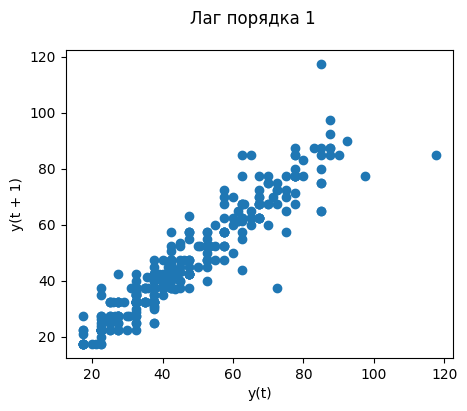

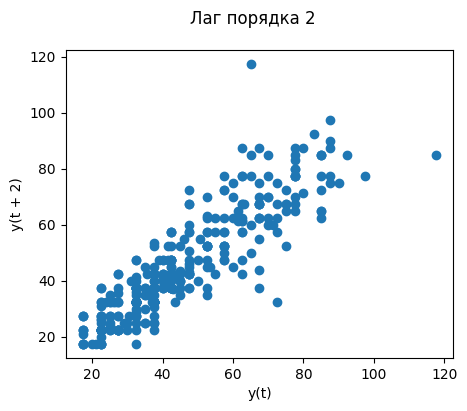

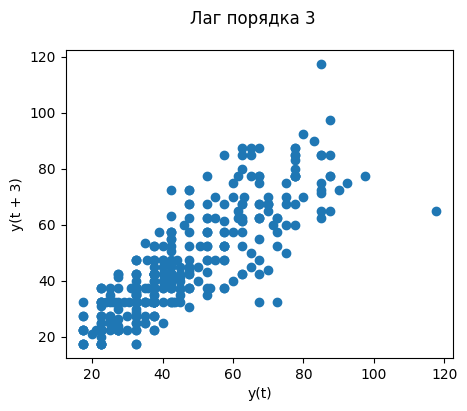

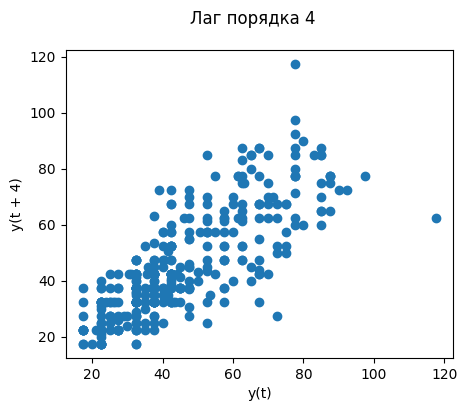

In [12]:
# Lag Plots (в данном случае положительная автокорреляция)
for i in range(1, 5):
    fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(5,4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(tomato_2019, lag=i, ax=ax)
    pyplot.show()

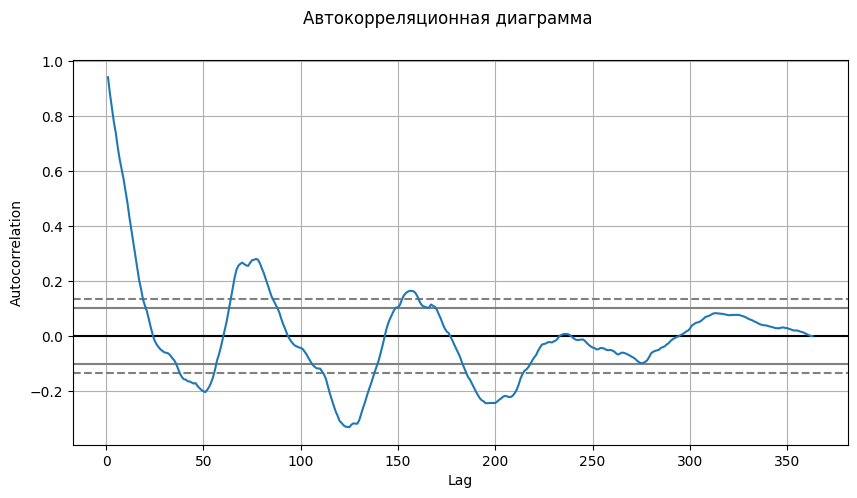

In [13]:
# По оси Y откладывается ковариация 
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(tomato_2019, ax=ax)
pyplot.show()

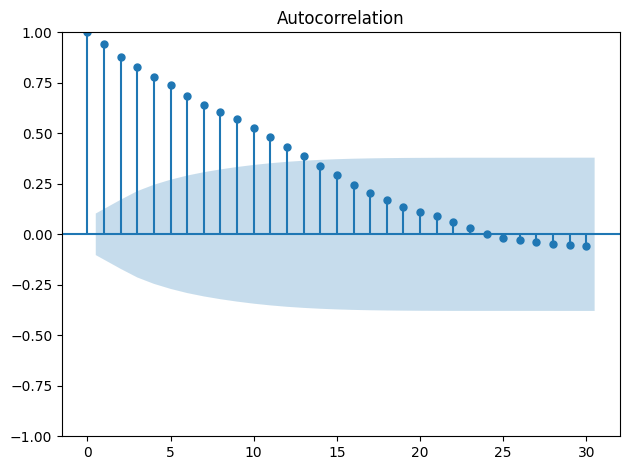

In [14]:
# автокорреляционная функция
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(tomato_2019, lags=30)
plt.tight_layout()


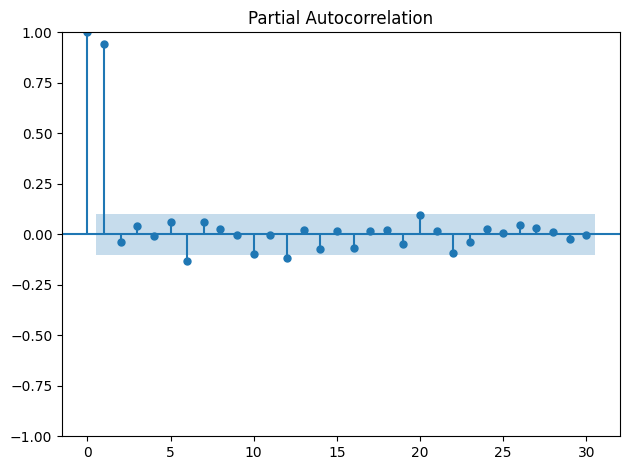

In [15]:
# частичная автокорреляционная функция
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(tomato_2019, lags=30)
plt.tight_layout()

In [16]:
# декомпозиция временного ряда
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

def plot_decompose(data=tomato_2019['Average'], model='add', period=7):
    result_add = seasonal_decompose(data, model=model, period=period)
    fig = result_add.plot()
    fig.set_size_inches((10, 8))
    fig.tight_layout()
    
    plt.close()
    
    plt.show()
    return fig

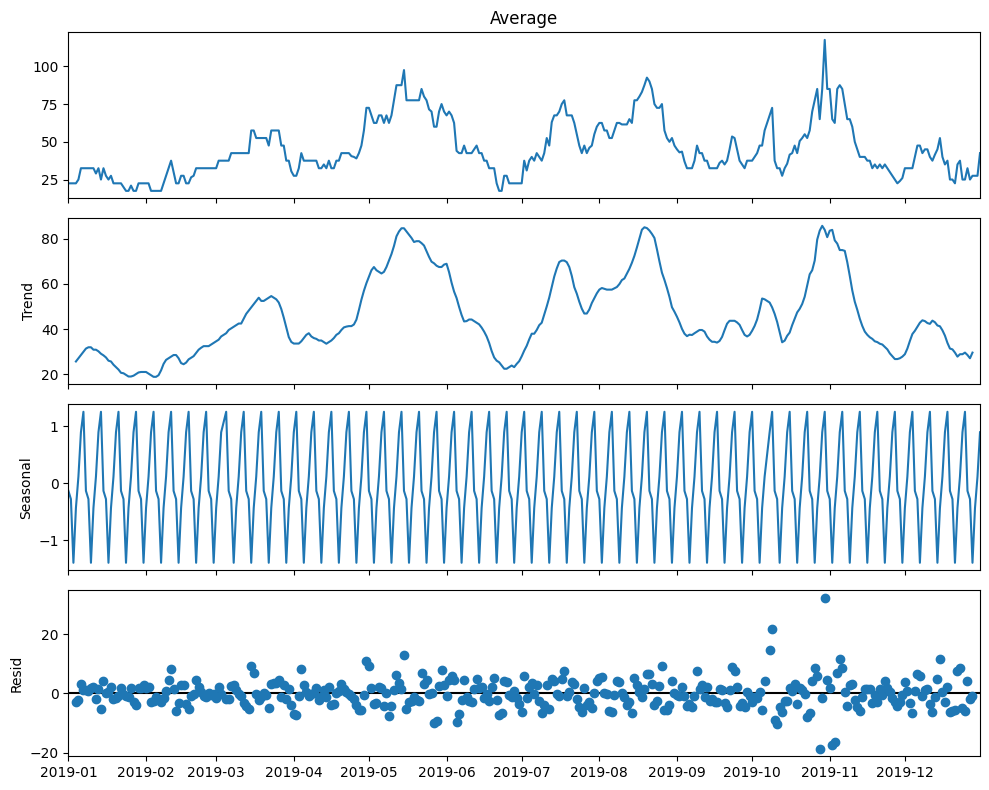

In [17]:
plot_decompose(data=tomato_2019['Average'], model='add')

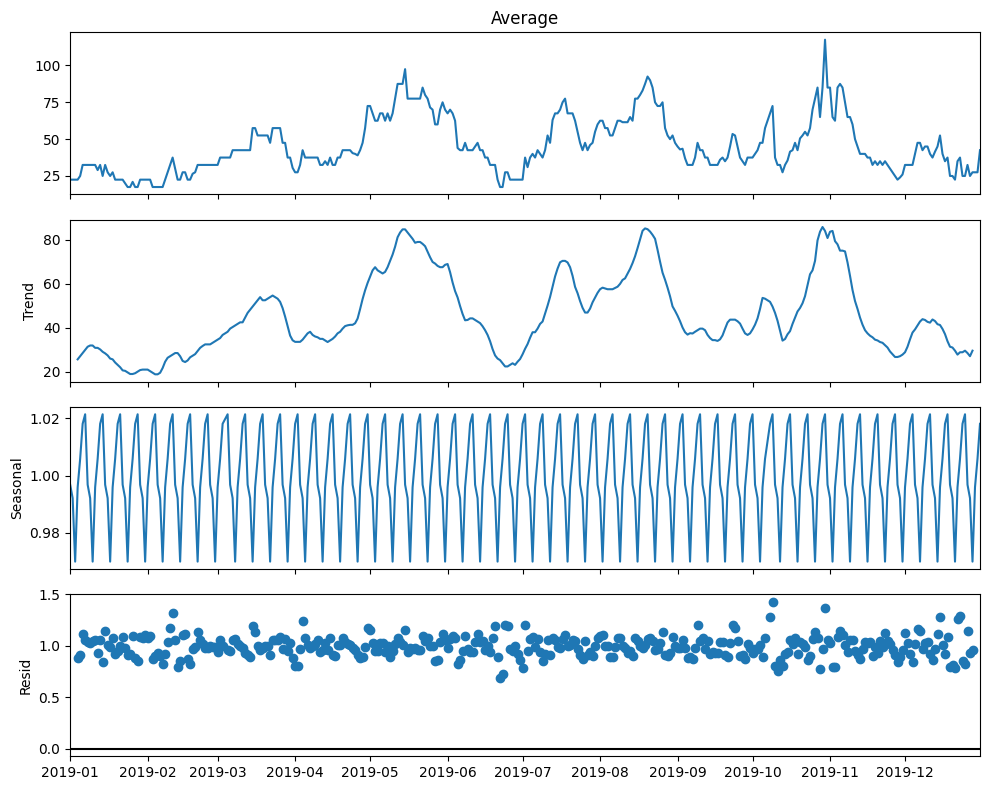

In [18]:
plot_decompose(data=tomato_2019['Average'], model='mul')

In [19]:
tomato_2019_2 = tomato_2019.copy()

In [20]:
# Простое скользящее среднее (SMA)
tomato_2019_2['SMA_10'] = tomato_2019_2['Average'].rolling(10, min_periods=1).mean()
tomato_2019_2['SMA_20'] = tomato_2019_2['Average'].rolling(20, min_periods=1).mean()

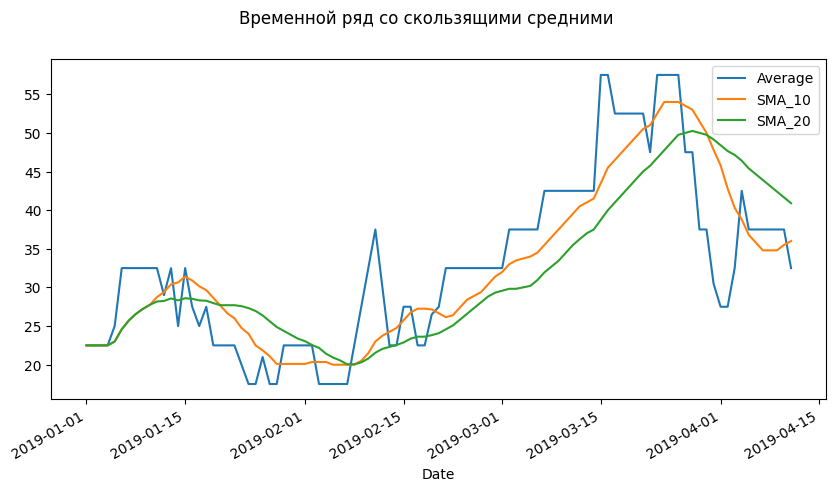

In [21]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд со скользящими средними')
tomato_2019_2[:100].plot(ax=ax, legend=True)
pyplot.show()

In [22]:
# Прогнозирование временного ряда авторегрессионными методами
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [23]:
# Целочисленная метка шкалы времени 
xnum = list(range(tomato_2019_2.shape[0]))
# Разделение выборки на обучающую и тестовую
Y = tomato_2019_2['Average'].values
train_size = int(len(Y) * 0.7)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]
print(f'размер ряда: {len(Y)} записей')
print(f'обучающая выборка: {len(train)} записи (с {tomato_2019_2.index[0].strftime("%Y-%m-%d")} по {tomato_2019_2.index[train_size-1].strftime("%Y-%m-%d")})')
print(f'тестовая выборка: {len(test)} записей (с {tomato_2019_2.index[train_size].strftime("%Y-%m-%d")} по {tomato_2019_2.index[-1].strftime("%Y-%m-%d")})')

размер ряда: 363 записей
обучающая выборка: 254 записи (с 2019-01-01 по 2019-09-12)
тестовая выборка: 109 записей (с 2019-09-13 по 2019-12-31)


In [24]:
# Параметры модели (p,d,q) 
arima_order = (6,1,1)
# Формирование предсказаний
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Вычисление метрики RMSE
error_arima = mean_squared_error(test, predictions_arima)

In [25]:
# Формирование предсказаний
predictions_es = list()
for t in range(len(test)):
    model_es = ExponentialSmoothing(history_es)
    model_es_fit = model_es.fit()
    yhat_es = model_es_fit.forecast()[0]
    predictions_es.append(yhat_es)
    history_es.append(test[t])
# Вычисление метрики RMSE
error_es = mean_squared_error(test, predictions_es)

In [26]:
# Ошибка прогноза
np.mean(Y), error_arima, error_es

(np.float64(45.41046831955923), 77.48072265210988, 73.34547900498502)

In [27]:
# Записываем предсказания в DataFrame
tomato_2019_2['predictions_ARIMA'] = (train_size * [np.nan]) + list(predictions_arima)
tomato_2019_2['predictions_HWES'] = (train_size * [np.nan]) + list(predictions_es)

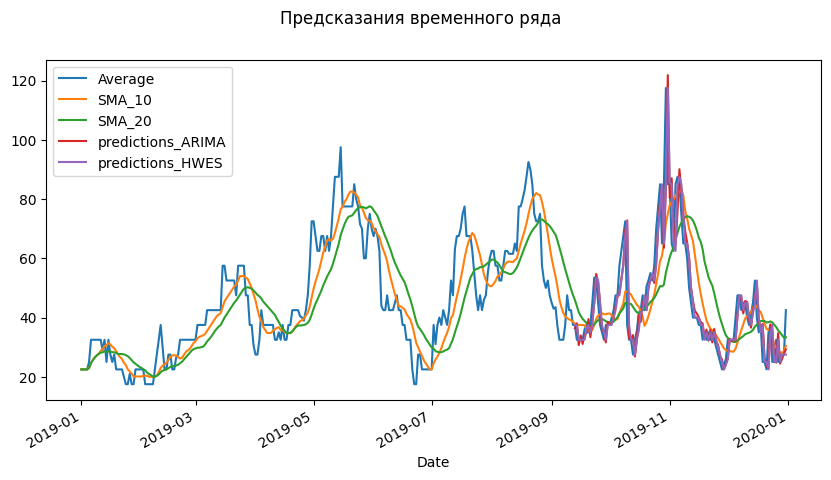

In [28]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда')
tomato_2019_2.plot(ax=ax, legend=True)
pyplot.show()

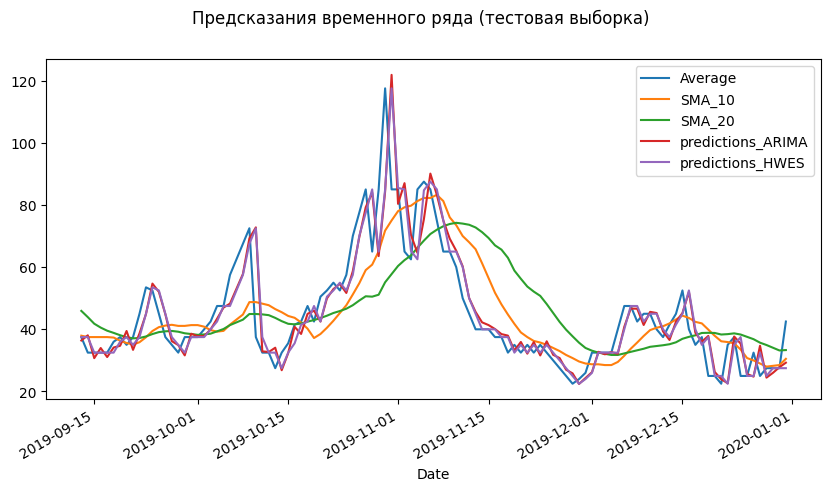

In [29]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
tomato_2019_2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

In [30]:
%pip install gplearn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
import gplearn

In [32]:
from gplearn.genetic import SymbolicRegressor

In [33]:
#обучение
function_set = ['add', 'sub', 'mul', 'div', 'sin']
est_gp = SymbolicRegressor(population_size=500, metric='mse',
                               generations=100, stopping_criteria=0.01,
                               init_depth=(4, 10), verbose=1, function_set=function_set,
                               const_range=(-100, 100), random_state=0)

In [34]:
est_gp.fit(np.array(xnum_train).reshape(-1, 1), train.reshape(-1, 1))

    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


   0   263.65      2.36512e+56       26          524.786              N/A     54.69s
   1   162.49      3.01538e+11      190          358.646              N/A     20.70s
   2   202.07      7.37149e+21      198          357.811              N/A     22.74s
   3   128.12      1.84467e+21       32          286.967              N/A     18.10s
   4   184.97      7.43589e+11       31          285.666              N/A     21.89s
   5   149.95      4.70626e+22       33          262.509              N/A     18.96s
   6    44.36      3.69544e+14       32          261.866              N/A     11.70s
   7    50.05      2.91436e+12       30          259.275              N/A     11.96s
   8    63.01      1.02278e+09       40          258.246              N/A     13.75s
   9    47.31      3.72653e+10       77          254.428              N/A     11.99s
  10    47.98      3.34114e+10      103          254.344              N/A     12.06s
  11    60.80      2.88665e+10       75          247.204         

,population_size,500
,generations,100
,tournament_size,20
,stopping_criteria,0.01
,const_range,"(-100, ...)"
,init_depth,"(4, ...)"
,init_method,'half and half'
,function_set,"['add', 'sub', ...]"
,metric,'mse'
,parsimony_coefficient,0.001
,p_crossover,0.9


In [35]:
# Предсказания
y_gp = est_gp.predict(np.array(xnum_test).reshape(-1, 1))
y_gp[:10]

array([39.15736837, 39.03787867, 38.96880076, 38.82143197, 38.49710635,
       37.96053714, 37.24417968, 36.42772326, 35.60829363, 34.87493223])

In [36]:
# Записываем предсказания в DataFrame
tomato_2019_2['predictions_GPLEARN'] = (train_size * [np.nan]) + list(y_gp)

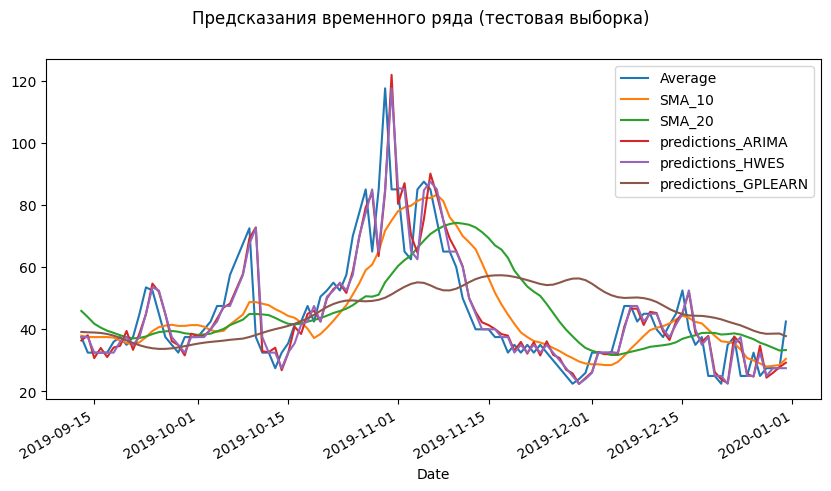

In [37]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда (тестовая выборка)')
tomato_2019_2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

In [38]:
from gmdhpy.gmdh import Regressor

In [39]:
def create_lags(series, n_lags=5):
    """Создание матрицы признаков из предыдущих значений"""
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i-n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

n_lags = 5
X_all, y_all = create_lags(tomato_2019_2.values, n_lags)

# Разделение
split_idx = int(len(X_all) * 0.7)
X_train, X_test = X_all[:split_idx], X_all[split_idx:]
y_train, y_test = y_all[:split_idx], y_all[split_idx:]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (250, 5, 6), y_train: (250, 6)
X_test: (108, 5, 6), y_test: (108, 6)


In [40]:
from gmdhpy.gmdh import MultilayerGMDH, RefFunctionType

In [41]:
def create_lag_df(series, lags=7):
    df = pd.DataFrame(series, columns=['y'])
    for lag in range(1, lags + 1):
        df[f'lag{lag}'] = df['y'].shift(lag)
    return df.dropna()

df_train = create_lag_df(pd.Series(train), lags=7)
y_train_gmdh = df_train['y'].values
X_train_gmdh = df_train.drop('y', axis=1).values

In [43]:
#COMBI
print('Обучение COMBI (линейный МГУА)')
combi = MultilayerGMDH(ref_functions=RefFunctionType.rfLinear)
combi.fit(X_train_gmdh, y_train_gmdh)

predictions_combi = list()
history_combi = [x for x in train]
for t in range(len(test)):
    last_7 = history_combi[-7:]
    if len(last_7) == 7:
        yhat_combi = combi.predict(np.array(last_7).reshape(1, -1))[0]
    else:
        yhat_combi = history_combi[-1]
    predictions_combi.append(yhat_combi)
    history_combi.append(test[t])
tomato_2019_2['COMBI'] = np.nan
# первые 254 дня=nan
combi_index = tomato_2019_2.index[254:]  
tomato_2019_2.loc[combi_index, 'COMBI'] = predictions_combi

Обучение COMBI (линейный МГУА)
train layer0 in 0.01 sec
train layer1 in 0.03 sec


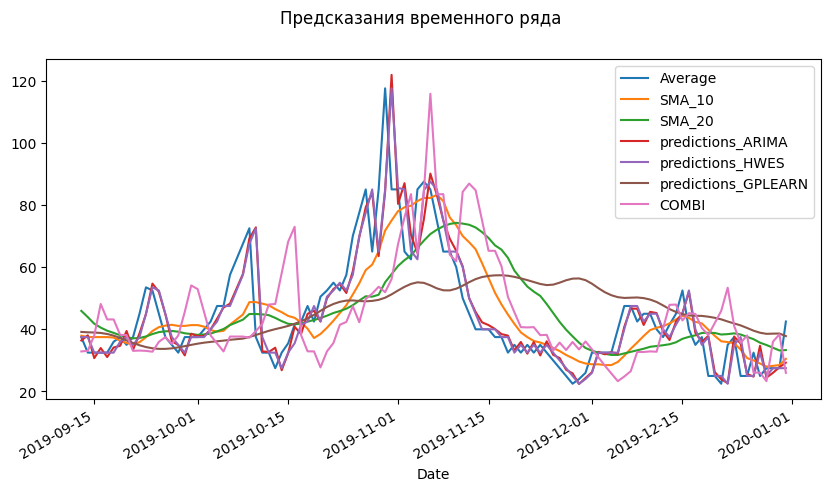

In [44]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда')
tomato_2019_2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

In [45]:
#MIA
print('Обучение MIA (нелинейный МГУА)')
mia = MultilayerGMDH(ref_functions=[RefFunctionType.rfLinear, 
                                     RefFunctionType.rfLinearCov,
                                     RefFunctionType.rfQuadratic,
                                     RefFunctionType.rfCubic])
mia.fit(X_train_gmdh, y_train_gmdh)

predictions_mia = list()
history_mia = [x for x in train]
for t in range(len(test)):
    last_7 = history_mia[-7:]
    if len(last_7) == 7:
        yhat_mia = mia.predict(np.array(last_7).reshape(1, -1))[0]
    else:
        yhat_mia = history_mia[-1]
    predictions_mia.append(yhat_mia)
    history_mia.append(test[t])
tomato_2019_2['MIA'] = np.nan
# первые 254 дня=nan
mia_index = tomato_2019_2.index[254:] 
tomato_2019_2.loc[mia_index, 'MIA'] = predictions_mia

Обучение MIA (нелинейный МГУА)
train layer0 in 0.05 sec
train layer1 in 0.10 sec


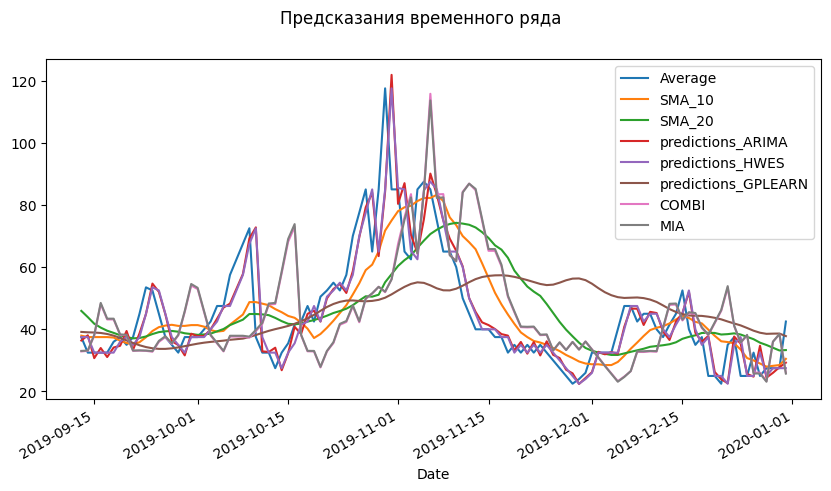

In [46]:
fig, ax = pyplot.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Предсказания временного ряда')
tomato_2019_2[train_size:].plot(ax=ax, legend=True)
pyplot.show()

In [53]:
#расчёт метрик
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
#ARIMA
rmse_arima = np.sqrt(mean_squared_error(test, predictions_arima))
mae_arima = mean_absolute_error(test, predictions_arima)
mape_arima = np.mean(np.abs((test - predictions_arima) / test)) * 100

#символьная регрессия (с учётом сдвига на 7)
rmse_gp = np.sqrt(mean_squared_error(test, y_gp))
mae_gp = mean_absolute_error(test, y_gp)
mape_gp = np.mean(np.abs((test - y_gp) / test)) * 100

#COMBI
rmse_combi = np.sqrt(mean_squared_error(test, predictions_combi))
mae_combi = mean_absolute_error(test, predictions_combi)
mape_combi = np.mean(np.abs((test - predictions_combi) / test)) * 100

#MIA
rmse_mia = np.sqrt(mean_squared_error(test, predictions_mia))
mae_mia = mean_absolute_error(test, predictions_mia)
mape_mia = np.mean(np.abs((test - predictions_mia) / test)) * 100

In [54]:
#сводная таблица результатов
print(" ")
print('Сводная таблица качества прогноза')
print(" ")
print(f'{"Метод":<25}  {"MAPE (%)":>12}   {"RMSE (руб/кг)":>12}  {"MAE (руб/кг)":>12}')
print(f'{"ARIMA":<25} {mape_arima:>12.4f} {rmse_arima:>12.4f} {mae_arima:>12.4f}')
print(f'{"Символьная регрессия":<25} {mape_gp:>12.4f} {rmse_gp:>12.4f} {mae_gp:>12.4f}')
print(f'{"COMBI (лин. МГУА)":<25} {mape_combi:>12.4f}  {rmse_combi:>12.4f} {mae_combi:>12.4f}')
print(f'{"MIA (нелин. МГУА)":<25} {mape_mia:>12.4f}  {rmse_mia:>12.4f} {mae_mia:>12.4f}')
print(" ")
print(f'Среднее значение ряда: {np.mean(Y):.4f}')
print(f'Стд. отклонение ряда:  {np.std(Y):.4f}')

 
Сводная таблица качества прогноза
 
Метод                          MAPE (%)   RMSE (руб/кг)  MAE (руб/кг)
ARIMA                          12.3618       8.8023       5.7483
Символьная регрессия           33.7897      17.7995      13.7868
COMBI (лин. МГУА)              32.4105       18.1403      14.1836
MIA (нелин. МГУА)              32.6545       18.1652      14.2306
 
Среднее значение ряда: 45.4105
Стд. отклонение ряда:  18.6071
